In [64]:

from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats



In [65]:
import dtreeviz


In [66]:
import kagglehub

kagglehub.login()

path = kagglehub.dataset_download("divaniazzahra/mental-health-dataset")

print("Path to dataset files: ", path)

Path to dataset files:  /Users/raymundomc/.cache/kagglehub/datasets/divaniazzahra/mental-health-dataset/versions/1


In [67]:
import os
print("Files inside: ", os.listdir(path))

csv_path = os.path.join(path,"Mental Health Dataset.csv")
df = pd.read_csv(csv_path)




Files inside:  ['Mental Health Dataset.csv']


In [68]:
print("Null Check: \n")
print(df.isna().sum())

Null Check: 

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64


In [69]:
# df.dropna(subset=["self_employed"],inplace=True)

# print("Null Check: \n")
# df.isna().sum()

In [70]:
known = df[df["self_employed"].notna()]
missing = df[df["self_employed"].isna()]

# these are the features that will help me predict whether one is self employed or in corporate
features = [
    "Gender", "Country", "Occupation", "family_history",
    "treatment", "Days_Indoors", "Growing_Stress",
    "Changes_Habits", "Mental_Health_History",
    "Mood_Swings", "Coping_Struggles", "Work_Interest",
    "Social_Weakness", "mental_health_interview",
    "care_options"
]


# these are the imports I need to help me encode the values instead of NaN values
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# training variables, just assignment what the features to test on the target variable
X_train = known[features]
y_train = known["self_employed"]


# encoding being done
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features)
    ]
)


model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])


model.fit(X_train, y_train)

predicted = model.predict(missing[features])
df.loc[df["self_employed"].isna(), "self_employed"] = predicted



In [71]:
df["Occupation"].values

array(['Corporate', 'Corporate', 'Corporate', ..., 'Business', 'Business',
       'Business'], shape=(292364,), dtype=object)

In [72]:
df.head(10)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
5,2014-08-27 11:49:51,Female,Poland,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Not sure
6,2014-08-27 11:51:34,Female,Australia,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
7,2014-08-27 11:52:41,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
8,2014-08-27 12:18:38,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
9,2014-08-27 12:37:50,Female,United States,Corporate,No,No,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No


In [73]:
x = df.columns

print("Columns:\n")

for e in x:
    print(e)

Columns:

Timestamp
Gender
Country
Occupation
self_employed
family_history
treatment
Days_Indoors
Growing_Stress
Changes_Habits
Mental_Health_History
Mood_Swings
Coping_Struggles
Work_Interest
Social_Weakness
mental_health_interview
care_options


In [74]:
print("Null Check: \n")
print(df.isna().sum())

Null Check: 

Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64


In [75]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,734,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,2014-08-27 12:31:41,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,780,239850,171308,66351,263196,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [76]:
features = ["Gender","self_employed","family_history","Days_Indoors","Growing_Stress"]
target = ["treatment"]
cols_to_get = ["Gender","self_employed","family_history","Days_Indoors","Growing_Stress","treatment"]

alter_df = df.loc[:,cols_to_get]





In [77]:
alter_df.isna().sum()

Gender            0
self_employed     0
family_history    0
Days_Indoors      0
Growing_Stress    0
treatment         0
dtype: int64

In [78]:
from pandas.api.types import is_string_dtype
from pandas.api.types import is_numeric_dtype


alter_df.dtypes

Gender            object
self_employed     object
family_history    object
Days_Indoors      object
Growing_Stress    object
treatment         object
dtype: object

In [79]:
alter_df["Days_Indoors"].unique()

array(['1-14 days', 'Go out Every day', 'More than 2 months',
       '15-30 days', '31-60 days'], dtype=object)

In [80]:
alter_df["self_employed"].unique()

array(['No', 'Yes'], dtype=object)

In [81]:
alter_df["family_history"].unique()

array(['No', 'Yes'], dtype=object)

In [82]:
alter_df["Growing_Stress"].unique()

array(['Yes', 'No', 'Maybe'], dtype=object)

In [83]:
alter_df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [84]:
alter_df["treatment"].unique()

array(['Yes', 'No'], dtype=object)

In [85]:
alter_df.head(3)

mappings = {
    'Gender': {'Female': 0, 'Male': 1},
    'self_employed': {'No': 0, 'Yes': 1},
    'family_history': {'No': 0, 'Yes': 1},
    'treatment': {'No': 0, 'Yes': 1},
    'Growing_Stress': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Days_Indoors': {
        'Go out Every day': 0,
        '1-14 days': 1,
        '15-30 days': 2,
        '31-60 days': 3,
        'More than 2 months': 4
    }
}


for col, mapping in mappings.items():
    if col in alter_df.columns:
        alter_df[col] = alter_df[col].map(mapping)

print(alter_df.head())

   Gender  self_employed  family_history  Days_Indoors  Growing_Stress  \
0       0              0               0             1               2   
1       0              0               1             1               2   
2       0              0               1             1               2   
3       0              0               1             1               2   
4       0              0               1             1               2   

   treatment  
0          1  
1          1  
2          1  
3          1  
4          1  


In [86]:
X = alter_df.drop('treatment', axis=1)
y = alter_df['treatment']



In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 233891
Testing rows: 58473


In [93]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

y_data = df[target].values.flatten()

tree_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_classifier.fit(alter_df[features].values, alter_df[target].values)

# 1. Use alter_df for both X and y
X_viz = alter_df[features]
y_viz = alter_df[target].values.flatten() # Ensures it's a 1D numerical array

# 2. Initialize with the encoded dataframe
viz_model = dtreeviz.model(
    tree_classifier,
    X_train=X_viz,
    y_train=y_viz,
    feature_names=features,
    target_name=target,
    class_names=["No", "Yes"]
)



Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


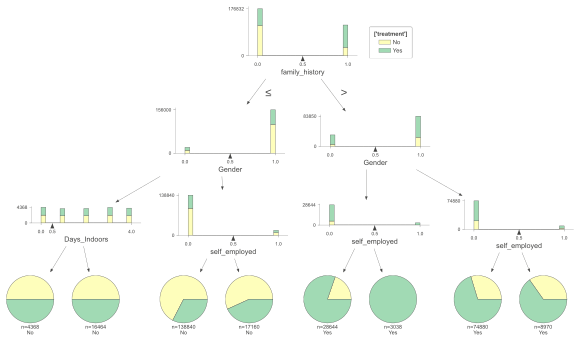

In [94]:
# 3. View
viz_model.view(scale=0.8)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


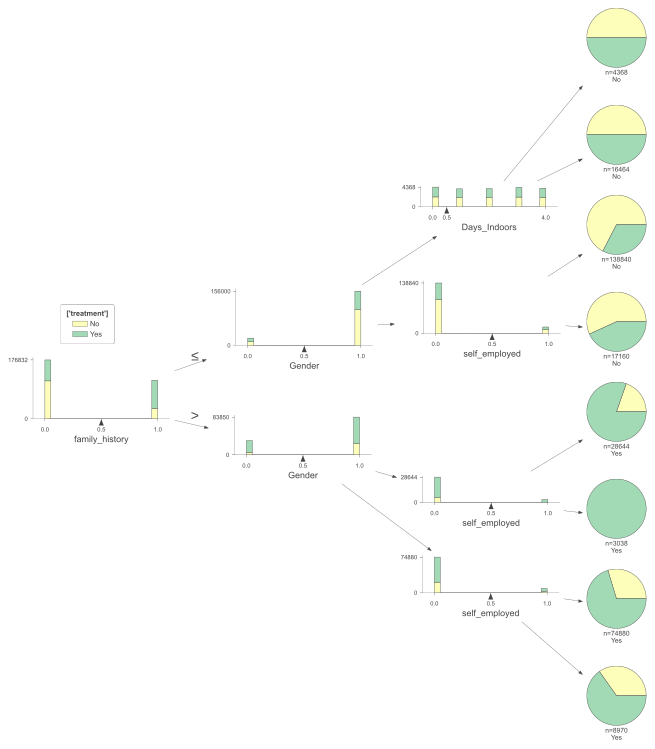

In [95]:
viz_model.view(orientation="LR")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


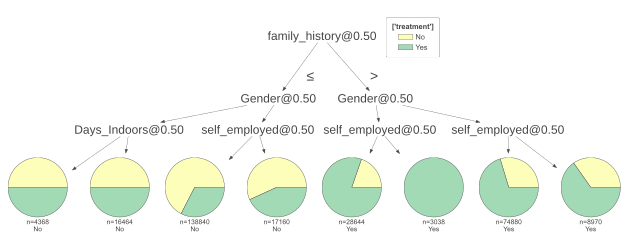

In [97]:
viz_model.view(fancy=False)

In [96]:
x = alter_df[features].iloc[10]
x

Gender            0
self_employed     0
family_history    1
Days_Indoors      1
Growing_Stress    2
Name: 10, dtype: int64

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dtreeviz/models/shadow_decision_tree.py:335: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dtreeviz/trees.py:1231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adj

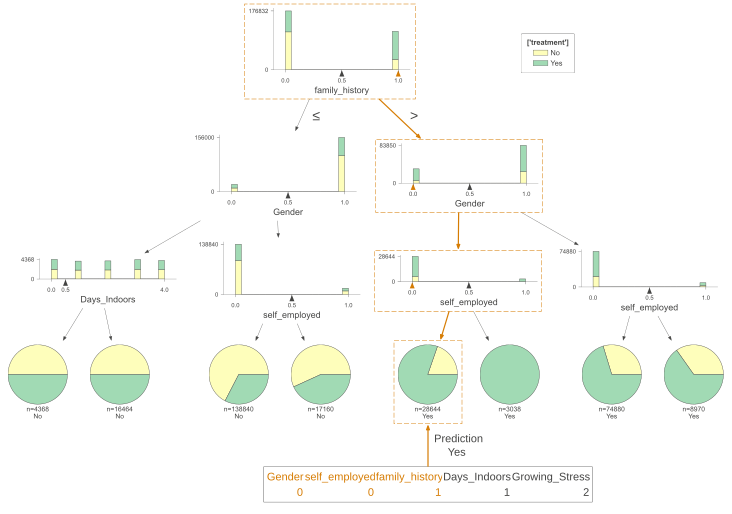

In [98]:
viz_model.view(x=x)